Taller EDA

In [1]:
import pandas as pd
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("pharmacy_otc_sales_data.csv")

print(df.head(2)) 

#print(df.shape) #muestra columnas y filas 

         Date              Product  Sales Person  Boxes Shipped  Amount ($)  \
0  2022-02-06  Pain Relief Tablets   Divya Mehra              7       67.43   
1  2022-02-05     Antiseptic Cream  Nikhil Batra             18      421.46   

     Country  
0  Australia  
1     Canada  


In [3]:
print(f"datos faltantes o nulos", df.isnull().sum())   #muestra datos faltanes, en este caso no hay

print(f"datos duplicados" ,df.duplicated().sum())
df_ordenado= df.sort_values(by="Country")
#print(df[df["Country"] == "USA"])

print(df_ordenado)

datos faltantes o nulos Date             0
Product          0
Sales Person     0
Boxes Shipped    0
Amount ($)       0
Country          0
dtype: int64
datos duplicados 0
           Date              Product  Sales Person  Boxes Shipped  Amount ($)  \
0    2022-02-06  Pain Relief Tablets   Divya Mehra              7       67.43   
246  2022-03-23        Allergy Pills    Sneha Iyer             19      335.15   
249  2022-01-28     Antiseptic Cream  Rajesh Patel              7       65.17   
121  2022-02-08          Cough Syrup    Sneha Iyer             10      159.21   
254  2022-02-20     Antiseptic Cream    Aman Verma              8       81.36   
..          ...                  ...           ...            ...         ...   
250  2022-01-16            Eye Drops   Divya Mehra              3       27.98   
124  2022-07-28     Digestive Enzyme   Ritika Shah              1       22.99   
129  2022-04-03     Digestive Enzyme  Rajesh Patel              3       40.32   
76   2022-07-31     

In [4]:
#Pregunta 1, Sacar promedio de ventas por pais
Promedio_ventas= df.groupby("Country")["Amount ($)"].mean().round(2)
print(f'este es el promedio de ventas por ' , Promedio_ventas)

este es el promedio de ventas por  Country
Australia    182.99
Canada       184.11
India        173.78
UK           162.60
USA          183.24
Name: Amount ($), dtype: float64


In [5]:
#Pregunta 2, Producto mas vendido
producto_mas_vendido= df.groupby("Product")["Boxes Shipped"].sum().sort_values(ascending=False).head(1)
print(f'Este es el producto mas vendido {producto_mas_vendido.index[0]}, con {producto_mas_vendido.values[0]} Unidades' )

Este es el producto mas vendido Digestive Enzyme, con 612 Unidades


In [6]:
#Pregunta 3, Producto menos vendido
producto_menos_vendido= df.groupby("Product")["Boxes Shipped"].sum().sort_values(ascending=True).head(1)
print(f'este es el producto menos vendido: {producto_menos_vendido.index[0]} con {producto_menos_vendido.values[0]} unidades')

este es el producto menos vendido: Pain Relief Tablets con 354 unidades


In [7]:
#Pregunta 4, Top seller
top_seller= df.groupby("Sales Person")["Amount ($)"].sum().head(1)
print (f'Este es el top seller', top_seller)

Este es el top seller Sales Person
Aman Verma    7039.07
Name: Amount ($), dtype: float64


In [8]:
#Pregunta 4, Top seller
top_seller= df.groupby("Sales Person")["Amount ($)"].sum().head(1)
print (f'Este es el top seller', top_seller)


Este es el top seller Sales Person
Aman Verma    7039.07
Name: Amount ($), dtype: float64


In [9]:
#pregunta 5, mes con mayores ventas
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df["Month Name"] = df["Date"].dt.strftime("%B")
Mes_mayor_ventas =df.groupby("Month Name")["Amount ($)"].sum().sort_values(ascending=False).head(1)
print(f'Este es el mes con mayor ventas', Mes_mayor_ventas)


Este es el mes con mayor ventas Month Name
May    8885.0
Name: Amount ($), dtype: float64


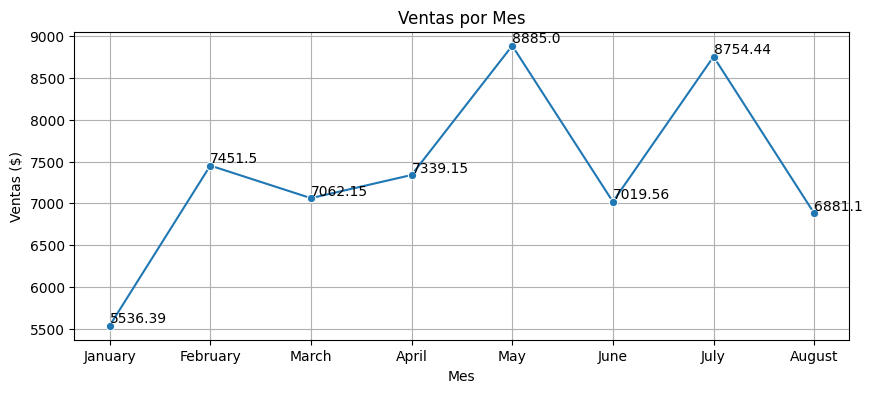

In [10]:
# Crear columna de meses
df["Mes"] = df["Date"].dt.strftime("%B")

# Agrupar ventas por mes
df_line = df.groupby("Mes")["Amount ($)"].sum().reset_index()

# Orden correcto de meses
orden_meses = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Ordenar meses
df_line["Mes"] = pd.Categorical(
    df_line["Mes"],
    categories=orden_meses,
    ordered=True
)

df_line = df_line.sort_values("Mes")

# Crear gráfico
plt.figure(figsize=(10,4))

sns.lineplot(
    data=df_line,
    x="Mes",
    y="Amount ($)",
    marker="o"
)

# Etiquetas de ventas
for i, txt in enumerate(df_line["Amount ($)"]):
    plt.text(
        df_line["Mes"].iloc[i],
        df_line["Amount ($)"].iloc[i],
        round(txt,2),
        ha='left',
        va='bottom'
    )

# Títulos
plt.title("Ventas por Mes")
plt.xlabel("Mes")
plt.ylabel("Ventas ($)")

plt.grid()

plt.show()